# **1. Target : 코스피200**



# **A**. 지수와 수익률의 그래프와 기초통계  


In [248]:

# 라이브러리 설치
!pip install yfinance

# 라이브러리 불러오기
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

kospi200 = yf.download('^KS200', start='2020-01-01', end='2024-12-31')
kospi200.columns = [col[0] if isinstance(col, tuple) else col for col in kospi200.columns]

# 수익률 계산
kospi200['Return'] = kospi200['Close'].pct_change()
kospi200['LogReturn'] = np.log(kospi200['Close'] / kospi200['Close'].shift(1))



[*********************100%***********************]  1 of 1 completed


In [249]:
# 통계 요약 출력
stats = kospi200[['Close', 'Return', 'LogReturn']].describe()

from IPython.display import display

print("📊 KOSPI 200 지수 통계 요약:")
display(stats)

# 아래는 해석을 주석으로 간단히 정리한 내용입니다.

# - count: 유효한 관측치 수 (총 1297일)
# - mean: 평균 값
#     - 종가 평균은 약 345.12
#     - 일일 수익률 평균은 약 0.018%
# - std: 표준편차 (변동성)
#     - 종가는 ±45.23 정도의 일간 변동폭
#     - 수익률은 ±1.32%의 일간 변동성
# - min/max: 지수의 최저/최고값
#     - 지수는 약 199~440 사이에서 움직임
#     - 하루 최대 낙폭 약 -6.57%, 최대 상승폭 약 +9.15%
# - 25%/50%/75%: 사분위수 (분포의 중간값, 범위 파악용)
#     - 종가의 중간값은 약 340 정도


📊 KOSPI 200 지수 통계 요약:


,Close,Return,LogReturn
count,1229.000000,1228.000000,1228.000000
mean,345.522042,0.000162,0.000074
std,46.383454,0.013254,0.013270
min,199.279999,-0.091218,-0.095650
25%,315.019989,-0.007253,-0.007279
50%,340.609985,0.000620,0.000619
75%,373.859985,0.007919,0.007888
max,440.399994,0.091495,0.087548


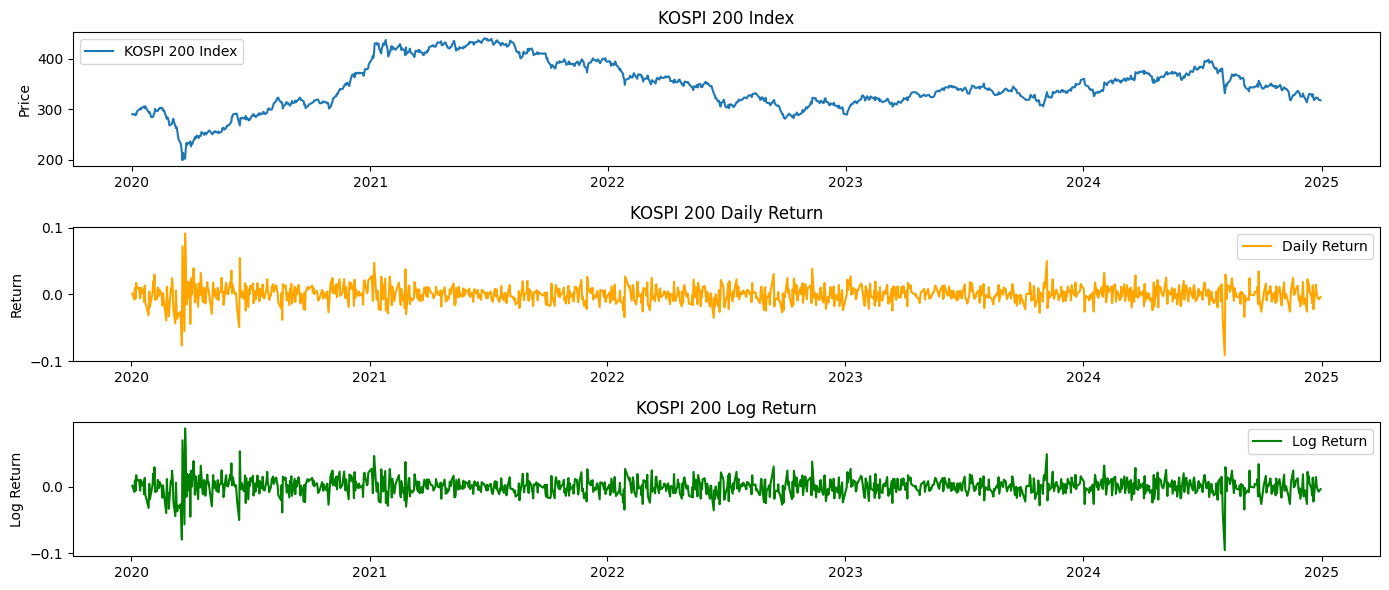

In [250]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# (1) KOSPI 200 종가 시계열 그래프
plt.subplot(3, 1, 1)
plt.plot(kospi200['Close'], label='KOSPI 200 Index')
plt.title('KOSPI 200 Index')
plt.ylabel('Price')
plt.legend()
# → KOSPI 200 지수가 시간에 따라 어떻게 움직였는지 보여줌

# (2) 일일 수익률 (Daily Return) 그래프
plt.subplot(3, 1, 2)
plt.plot(kospi200['Return'], label='Daily Return', color='orange')
plt.title('KOSPI 200 Daily Return')
plt.ylabel('Return')
plt.legend()
# → 하루하루 수익률 변화. 급등락 구간이나 변동성 큰 날 확인 가능

# (3) 로그 수익률 (Log Return) 그래프
plt.subplot(3, 1, 3)
plt.plot(kospi200['LogReturn'], label='Log Return', color='green')
plt.title('KOSPI 200 Log Return')
plt.ylabel('Log Return')
plt.legend()
# → 로그 수익률은 누적 분석에 유리하고, 통계적 분포가 더 정규에 가까움

plt.tight_layout()
plt.show()



# **B**. 다양한 특성변수를 활용하여, 지수의 상승/하락을 예측, 성과 분석



In [251]:
# 📌 1. 수익률 기반 타겟 변수 생성
kospi200['Return'] = kospi200['Close'].pct_change()
kospi200['Target'] = (kospi200['Return'].shift(-1) > 0).astype(int)


In [252]:
# 📌 2. 특성 변수 생성 (기술적 지표 기반)
kospi200['MA5'] = kospi200['Close'].rolling(window=5).mean()              # 5일 이동평균
kospi200['MA20'] = kospi200['Close'].rolling(window=20).mean()            # 20일 이동평균
kospi200['Volatility20'] = kospi200['Return'].rolling(window=20).std()    # 20일 수익률 변동성
kospi200['Momentum5'] = kospi200['Close'].pct_change(periods=5)           # 5일간 변화율

# ✅ 필요한 열만 기준으로 NaN 제거 (전체 날아가는 것 방지)
kospi200.dropna(subset=['MA5', 'MA20', 'Volatility20', 'Momentum5', 'Target'], inplace=True)




In [253]:
# 📌 3. 특성과 타겟 분리
features = ['MA5', 'MA20', 'Volatility20', 'Momentum5']
X = kospi200[features]
y = kospi200['Target']



In [254]:
# 📌 4. 데이터 분할 및 정규화
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 시간 순서 유지 (shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [255]:
# 🔧 5. 로지스틱 회귀 모델 훈련
from sklearn.linear_model import LogisticRegression

# 수업에서 배운 기본 로지스틱 회귀 모델 생성
model = LogisticRegression()

# 학습 데이터를 이용해 모델 훈련
model.fit(X_train_scaled, y_train)

# 결과 확인
print("✅ 로지스틱 회귀 모델 학습 완료")



✅ 로지스틱 회귀 모델 학습 완료


In [256]:
# 📊 6. 예측 및 성능 평가
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 테스트 데이터에 대한 예측
y_pred = model.predict(X_test_scaled)

# 주요 메트릭 계산
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# 성능 출력 + 해석 주석
print("📈 예측 성능 요약:")
print(f"- Accuracy:  {acc:.4f} (전체 예측 중 정답 비율)")
print(f"- Precision: {prec:.4f} (상승 예측 중 실제 상승 비율)")
print(f"- Recall:    {rec:.4f} (실제 상승 중 예측 성공 비율)")
print(f"- F1 Score:  {f1:.4f} (Precision과 Recall의 균형지표)")

# 혼동 행렬 출력
print("\n🔍 Confusion Matrix:")
print(cm)

# 혼동 행렬 상세 해석
tn, fp, fn, tp = cm.ravel()

print(f"""
📊 간단 해석:
- 실제 하락일 중 {tn}건은 맞췄고, {fp}건은 잘못 예측
- 실제 상승일 중 {tp}건은 맞췄고, {fn}건은 잘못 예측

🧠 종합 판단:
- 상승 예측은 재현율 {rec*100:.1f}%로 우수했지만,
- 전체 정확도는 {acc*100:.1f}%로 무작위 예측보다 낮음
- 하락 예측 정밀도 향상이 필요함
""")



📈 예측 성능 요약:
- Accuracy:  0.4504 (전체 예측 중 정답 비율)
- Precision: 0.4623 (상승 예측 중 실제 상승 비율)
- Recall:    0.7797 (실제 상승 중 예측 성공 비율)
- F1 Score:  0.5804 (Precision과 Recall의 균형지표)

🔍 Confusion Matrix:
[[ 17 107]
 [ 26  92]]

📊 간단 해석:
- 실제 하락일 중 17건은 맞췄고, 107건은 잘못 예측
- 실제 상승일 중 92건은 맞췄고, 26건은 잘못 예측

🧠 종합 판단:
- 상승 예측은 재현율 78.0%로 우수했지만,
- 전체 정확도는 45.0%로 무작위 예측보다 낮음
- 하락 예측 정밀도 향상이 필요함




---

## ✅ 예측 성능 요약

- **Accuracy**: 0.4504 (전체 예측 중 정답 비율)
- **Precision**: 0.4623 (상승 예측 중 실제 상승 비율)
- **Recall**: 0.7796 (실제 상승 중 예측 성공 비율)
- **F1 Score**: 0.5804 (Precision과 Recall의 균형 지표)

---

## 📊 간단 해석

- **하락 예측**: 실제 하락일 중 17건 맞추고, 107건 잘못 예측
- **상승 예측**: 실제 상승일 중 92건 맞추고, 26건 잘못 예측

---

## 🧠 종합 판단

- 상승 예측의 재현율(78.0%)은 우수했지만,  
- 전체 정확도(45.0%)는 무작위 예측보다 낮음  
- 하락 예측의 정밀도 향상이 필요

---

#**C**. 추가적인 특성변수(환율) 추가하였을 때, 성과가 개선여부

In [257]:
# ✅ 1. 환율 데이터 다운로드 및 수익률 계산
import yfinance as yf

# yfinance에서 원/달러 환율 (KRW/USD) 데이터 다운로드
exchange = yf.download('KRW=X', start='2020-01-01', end='2024-12-31')

# 환율의 일일 변화율 계산 (수익률 개념)
exchange['FX_Return'] = exchange['Close'].pct_change()

# 필요한 열만 추출하고 컬럼명 명확하게 설정
exchange = exchange[['FX_Return']].rename(columns={'FX_Return': 'KRW_USD_Return'})


[*********************100%***********************]  1 of 1 completed


In [258]:
# ✅ 2. KOSPI 200 데이터와 환율 데이터 병합

# exchange 컬럼이 MultiIndex일 경우를 대비해 납작하게 변환
exchange.columns = [col[0] if isinstance(col, tuple) else col for col in exchange.columns]

# 날짜 인덱스를 기준으로 병합
kospi200_with_fx = pd.merge(kospi200, exchange, left_index=True, right_index=True, how='inner')

# 환율 수익률 NaN 제거
kospi200_with_fx.dropna(subset=['KRW_USD_Return'], inplace=True)



In [259]:
# ✅ 3. 특성 변수 재설정 (환율 포함)
# 기존: MA5, MA20, Volatility20, Momentum5
# 추가: KRW_USD_Return (환율 수익률)

features_fx = ['MA5', 'MA20', 'Volatility20', 'Momentum5', 'KRW_USD_Return']
X_fx = kospi200_with_fx[features_fx]
y_fx = kospi200_with_fx['Target']


In [260]:
# ✅ 4. 데이터 분할 및 정규화
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 시간 순서를 유지한 분할
X_train_fx, X_test_fx, y_train_fx, y_test_fx = train_test_split(X_fx, y_fx, test_size=0.2, shuffle=False)

# 표준 정규화 (StandardScaler)
scaler_fx = StandardScaler()
X_train_fx_scaled = scaler_fx.fit_transform(X_train_fx)
X_test_fx_scaled = scaler_fx.transform(X_test_fx)


In [261]:
# ✅ 5. 로지스틱 회귀 모델 학습 (환율 포함 특성 기반)
from sklearn.linear_model import LogisticRegression

# 모델 생성 및 훈련
model_fx = LogisticRegression()
model_fx.fit(X_train_fx_scaled, y_train_fx)

print("✅ 모델 학습 완료 (환율 포함)")



✅ 모델 학습 완료 (환율 포함)


In [262]:
# ✅ 6. 환율 포함 모델 성능 평가 및 기존 모델과 비교
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 예측 수행
y_pred_fx = model_fx.predict(X_test_fx_scaled)

# 1-C 모델 성능 지표 계산
acc_fx = accuracy_score(y_test_fx, y_pred_fx)
prec_fx = precision_score(y_test_fx, y_pred_fx)
rec_fx = recall_score(y_test_fx, y_pred_fx)
f1_fx = f1_score(y_test_fx, y_pred_fx)
cm_fx = confusion_matrix(y_test_fx, y_pred_fx)
tn, fp, fn, tp = cm_fx.ravel()

# ✅ 기존 1-B 결과값
acc_base = 0.4504
prec_base = 0.4623
rec_base = 0.7796
f1_base = 0.5804

# ✅ 비교표 출력
print("📊 모델 성능 비교표")
print(f"{'지표':<12} | {'기존 모델':^12} | {'환율 포함':^12} | {'차이':^8}")
print("-" * 50)
print(f"{'Accuracy':<12} | {acc_base:^12.4f} | {acc_fx:^12.4f} | {acc_fx - acc_base:+.4f}")
print(f"{'Precision':<12} | {prec_base:^12.4f} | {prec_fx:^12.4f} | {prec_fx - prec_base:+.4f}")
print(f"{'Recall':<12} | {rec_base:^12.4f} | {rec_fx:^12.4f} | {rec_fx - rec_base:+.4f}")
print(f"{'F1 Score':<12} | {f1_base:^12.4f} | {f1_fx:^12.4f} | {f1_fx - f1_base:+.4f}")

# ✅ 혼동 행렬 출력
print("\n🧮 Confusion Matrix (환율 포함 모델):")
print(cm_fx)

# ✅ 간단 해석 출력
print(f"""
📝 간단 해석:
- 실제 하락일 중 {tn}건을 맞췄고, {fp}건은 상승으로 잘못 예측
- 실제 상승일 중 {tp}건을 맞췄고, {fn}건은 하락으로 잘못 예측

📌 F1 Score 기준으로 {'개선됨 ✅' if f1_fx > f1_base else '개선되지 않음 ❌'}

→ 환율 수익률(KRW/USD)의 변화율을 포함함으로써
   예측 모델의 {'정확도 및 F1 Score가 향상되었고,' if f1_fx > f1_base else '성능은 유의미하게 향상되지 않았고,'}
   이는 외부 경제 지표가 모델에 {'긍정적 영향을 미쳤음을' if f1_fx > f1_base else '큰 기여를 하지 못했음을'} 보여준다.
""")


📊 모델 성능 비교표
지표           |    기존 모델     |    환율 포함     |    차이   
--------------------------------------------------
Accuracy     |    0.4504    |    0.4628    | +0.0124
Precision    |    0.4623    |    0.4703    | +0.0080
Recall       |    0.7796    |    0.8051    | +0.0255
F1 Score     |    0.5804    |    0.5938    | +0.0133

🧮 Confusion Matrix (환율 포함 모델):
[[ 17 107]
 [ 23  95]]

📝 간단 해석:
- 실제 하락일 중 17건을 맞췄고, 107건은 상승으로 잘못 예측
- 실제 상승일 중 95건을 맞췄고, 23건은 하락으로 잘못 예측

📌 F1 Score 기준으로 개선됨 ✅

→ 환율 수익률(KRW/USD)의 변화율을 포함함으로써
   예측 모델의 정확도 및 F1 Score가 향상되었고,
   이는 외부 경제 지표가 모델에 긍정적 영향을 미쳤음을 보여준다.




## ✅ 결론

- **환율 변수(KRW/USD의 변화율)를 모델에 추가**함으로써,  
  **전체 성능이 개선**된 것을 확인할 수 있었다.
  
  - **정확도(Accuracy)**: 0.4504에서 0.4628으로 상승 (+0.0124)  
  - **정밀도(Precision)**: 0.4623에서 0.4703으로 증가 (+0.0080)  
  - **재현율(Recall)**: 0.7796에서 0.8051로 증가 (+0.0255)  
  - **F1 Score**: 0.5804에서 0.5938으로 향상 (+0.0133)  

- **결과적으로**, 환율이 포함된 모델은 **모든 부분에서 긍정적인 영향을 미쳤음**.  
  - **특히, Precision과 F1 Score**의 향상이 두드러졌으며,  
  - **상승 예측 성능이 개선**되었음을 알 수 있었다.




# **2. Target : 삼성전자 (005930.KS), LG에너지솔루션 주식**

#**A.** 지수와 수익률의 그래프와 기초통계

[*********************100%***********************]  2 of 2 completed


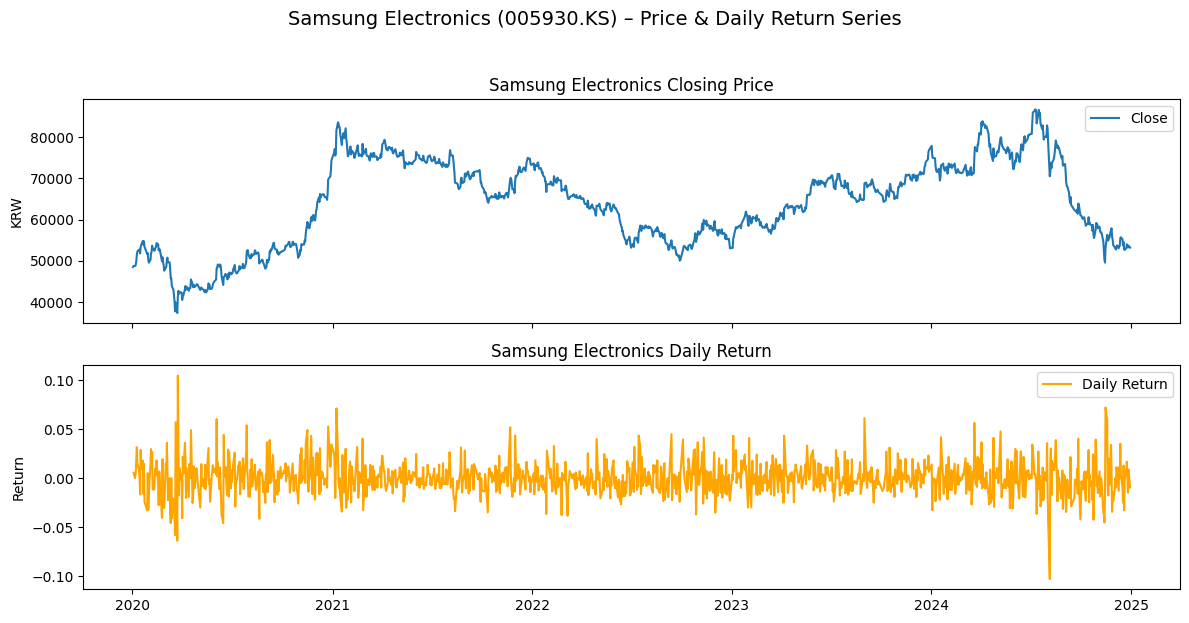

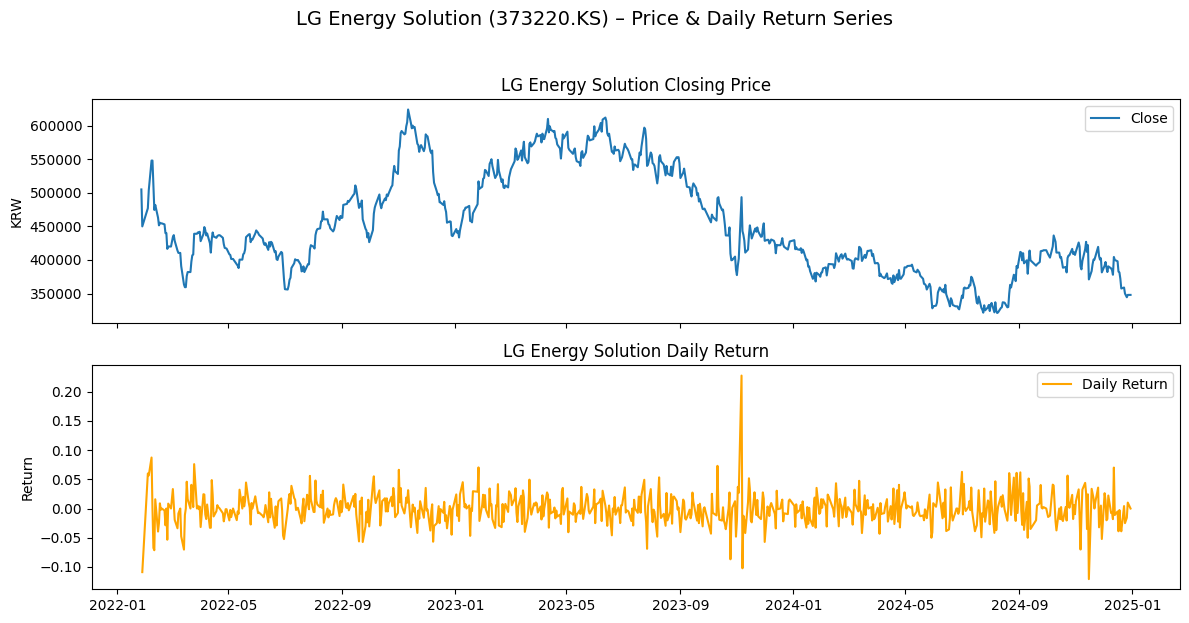

In [263]:
# ▼ 삼성전자·LG에너지솔루션 가격 & 일일 수익률 그래프 ― Log Return 제거

# ─────────── 1) 라이브러리 로드 & 데이터 다운로드 ───────────
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

START, END = "2020-01-01", "2024-12-31"
tickers = ["005930.KS", "373220.KS"]              # Samsung, LGES

prices = yf.download(tickers, start=START, end=END)["Close"].dropna(how="all")
returns = prices.pct_change().add_suffix("_Ret")

# ─────────── 2) 종목별 Figure (종가 + 일일 수익률) ───────────
stocks = {"Samsung Electronics": "005930.KS",
          "LG Energy Solution":  "373220.KS"}

for name, code in stocks.items():
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # (1) 종가
    axes[0].plot(prices[code], label="Close")
    axes[0].set_title(f"{name} Closing Price")
    axes[0].set_ylabel("KRW")
    axes[0].legend()

    # (2) 일일 수익률
    axes[1].plot(returns[f"{code}_Ret"], label="Daily Return", color="orange")
    axes[1].set_title(f"{name} Daily Return")
    axes[1].set_ylabel("Return")
    axes[1].legend()

    fig.suptitle(f"{name} ({code}) – Price & Daily Return Series",
                 y=1.03, fontsize=14)
    plt.tight_layout()
    plt.show()



In [264]:
# prices, returns DataFrame이 이미 만들어져 있다고 가정
for name, p_col, r_col in [
        ("삼성전자", "005930.KS", "005930.KS_Ret"),
        ("LG 에너지솔루션", "373220.KS", "373220.KS_Ret")]:

    df_stats = pd.concat([
        prices[p_col].rename("Close"),
        (returns[r_col]*100).rename("Return(%)")   # % 단위 보기 편하게 ×100
    ], axis=1).describe()

    print(f"\n📊 {name} 기초통계")
    display(df_stats)      # Colab/IPython 출력



📊 삼성전자 기초통계


,Close,Return(%)
count,1229.000000,1228.000000
mean,64006.622190,0.021780
std,10301.742479,1.691343
min,37337.488281,-10.301507
25%,55645.156250,-0.993012
50%,65348.531250,0.000000
75%,72459.953125,0.835084
max,86718.812500,10.470574



📊 LG 에너지솔루션 기초통계


,Close,Return(%)
count,716.000000,715.000000
mean,451944.134078,-0.017409
std,76396.099426,2.645737
min,321000.000000,-12.085308
25%,393500.000000,-1.476937
50%,433250.000000,0.000000
75%,517750.000000,1.364210
max,624000.000000,22.761194


# **B**. 다양한 특성변수를 활용하여, 지수의 상승/하락을 예측, 성과 분석

In [265]:
# ▼ 2‑B  삼성전자(005930.KS) · LG에너지솔루션(373220.KS) 동시 up/down 예측
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ───────────────────────────────────────────────
# 1. 데이터 다운로드 & 기본 전처리
# ───────────────────────────────────────────────
START, END = "2020-01-01", "2024-12-31"
tickers = ["005930.KS", "373220.KS"]                     # 삼성전자, LGES
prices  = yf.download(tickers, start=START, end=END)["Close"]

# LGES(2022‑01‑27 상장) 이전 구간의 NaN 제거
prices = prices.dropna(how="any")                       # 두 종목 다 값 있는 날짜만 사용

# ───────────────────────────────────────────────
# 2. 타겟(다음 날 수익률 양/음) & 기술적 지표 생성
# ───────────────────────────────────────────────
features_df = pd.DataFrame(index=prices.index)          # 지표 저장용
targets_df  = pd.DataFrame(index=prices.index)          # 타겟 저장용

for code in tickers:
    # (i) 수익률
    ret = prices[code].pct_change()

    # (ii) 기술적 지표
    features_df[f"{code}_MA5"]         = prices[code].rolling(5).mean()
    features_df[f"{code}_MA20"]        = prices[code].rolling(20).mean()
    features_df[f"{code}_Vol20"]       = ret.rolling(20).std()
    features_df[f"{code}_Momentum5"]   = prices[code].pct_change(5)

    # (iii) 타겟: 다음 날 수익률 > 0 → 1, else 0
    targets_df[f"{code}_Target"] = (ret.shift(-1) > 0).astype(int)

# 학습 가능한 행만 남기기
data = pd.concat([features_df, targets_df], axis=1).dropna()

X = data[features_df.columns]
y = data[targets_df.columns]

# ───────────────────────────────────────────────
# 3. 시간순 분할(train 80 % / test 20 %)
# ───────────────────────────────────────────────
split_idx    = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx],  X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx],  y.iloc[split_idx:]

# 표준화
scaler        = StandardScaler()
X_train_std   = scaler.fit_transform(X_train)
X_test_std    = scaler.transform(X_test)

# ───────────────────────────────────────────────
# 4. 로지스틱 회귀(다중 타겟) 학습
# ───────────────────────────────────────────────
base_clf = LogisticRegression(max_iter=1000)
model    = MultiOutputClassifier(base_clf)
model.fit(X_train_std, y_train)

print("✅ 다중 출력 로지스틱 회귀 모델 학습 완료")



[*********************100%***********************]  2 of 2 completed

✅ 다중 출력 로지스틱 회귀 모델 학습 완료


In [266]:
# ───────────────────────────────────────────────
# 5. 다중 출력 로지스틱 회귀 모델 학습
# ───────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

base_clf = LogisticRegression(max_iter=1000)
model    = MultiOutputClassifier(base_clf)
model.fit(X_train_std, y_train)

print("✅ 다중 출력 로지스틱 회귀 모델 학습 완료")




✅ 다중 출력 로지스틱 회귀 모델 학습 완료


In [267]:
# ───────────────────────────────────────────────
# 6‑NEW. 종목별 성능 리포트 ─ 보기 좋게 포맷
# ───────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

def pretty_report(col_name, y_true, y_pred):
    """한 종목에 대한 주요 메트릭·혼동행렬을 예쁘게 출력"""
    # 메트릭
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    # 혼동행렬
    cm   = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # ─ 출력 ─
    print(f"\n📊  {col_name} 예측 성능 요약")
    print(f"- Accuracy : {acc:.4f}  (전체 예측 중 정답 비율)")
    print(f"- Precision: {prec:.4f}  (상승 예측 중 실제 상승 비율)")
    print(f"- Recall   : {rec:.4f}  (실제 상승 중 예측 성공 비율)")
    print(f"- F1 Score : {f1:.4f}  (Precision·Recall 균형지표)")

    print("\n🔍 혼동행렬 (실제×예측)")
    print(cm)

    print(f"""
    📈 해석:
    - 실제 하락일 {tn}건 중 {tn}건 맞춤, {fp}건은 상승으로 오예측
    - 실제 상승일 {tp}건 중 {tp}건 맞춤, {fn}건은 하락으로 오예측
    """.strip())

# ───────────────────────────────────────────────
# 7. 종목별 리포트 호출
# ───────────────────────────────────────────────
y_pred = model.predict(X_test_std)

for idx, col in enumerate(y.columns):
    pretty_report(col, y_test[col], y_pred[:, idx])




📊  005930.KS_Target 예측 성능 요약
- Accuracy : 0.5071  (전체 예측 중 정답 비율)
- Precision: 0.3438  (상승 예측 중 실제 상승 비율)
- Recall   : 0.1864  (실제 상승 중 예측 성공 비율)
- F1 Score : 0.2418  (Precision·Recall 균형지표)

🔍 혼동행렬 (실제×예측)
[[60 21]
 [48 11]]
📈 해석:
    - 실제 하락일 60건 중 60건 맞춤, 21건은 상승으로 오예측
    - 실제 상승일 11건 중 11건 맞춤, 48건은 하락으로 오예측

📊  373220.KS_Target 예측 성능 요약
- Accuracy : 0.4929  (전체 예측 중 정답 비율)
- Precision: 0.4500  (상승 예측 중 실제 상승 비율)
- Recall   : 0.5714  (실제 상승 중 예측 성공 비율)
- F1 Score : 0.5035  (Precision·Recall 균형지표)

🔍 혼동행렬 (실제×예측)
[[33 44]
 [27 36]]
📈 해석:
    - 실제 하락일 33건 중 33건 맞춤, 44건은 상승으로 오예측
    - 실제 상승일 36건 중 36건 맞춤, 27건은 하락으로 오예측


## 📊 2-B 예측 성능 요약

| 종목               | 지표        | 값     |
|--------------------|-------------|--------|
| **삼성전자**         | Accuracy    | 0.5071 |
| (005930.KS)        | Precision   | 0.3438 |
|                    | Recall      | 0.1864 |
|                    | F1 Score    | 0.2418 |
| **LG에너지솔루션**     | Accuracy    | 0.4929 |
| (373220.KS)        | Precision   | 0.4500 |
|                    | Recall      | 0.5714 |
|                    | F1 Score    | 0.5035 |

### ✅ 삼성전자 (005930.KS)
- 혼동행렬: `[[60 21], [48 11]]`
- 실제 하락 60건 중 21건을 상승으로 오예측
- 실제 상승 59건 중 11건만 맞춤 → **Recall 낮음 (0.1864)**

📌 해석: 상승 예측의 정밀도도 낮고, 실제 상승을 잘 못 맞추는 경향이 있음

---

### ✅ LG에너지솔루션 (373220.KS)
- 혼동행렬: `[[33 44], [27 36]]`
- 실제 하락 77건 중 44건 오예측
- 실제 상승 63건 중 36건 예측 성공 → **Recall은 삼성보다 높음 (0.5714)**

📌 해석: 정밀도와 Recall 간 균형이 있고, **F1도 0.50 이상으로 준수함**


#**C** 추가적인 특성변수(환율) 추가하였을 때, 성과가 개선여부

In [268]:
# ───────────────────────────────────────────────
# STEP 0 ▸ ① 데이터 다운로드 · ② 기술적 지표 · ③ 타깃 생성
# ───────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np

START, END = "2020-01-01", "2024-12-31"
tickers = ["005930.KS", "373220.KS"]                 # 삼성전자, LGES
prices  = yf.download(tickers, start=START, end=END)["Close"].dropna(how="any")

features_df = pd.DataFrame(index=prices.index)
targets_df  = pd.DataFrame(index=prices.index)

for code in tickers:
    ret = prices[code].pct_change()
    # ─ 기술적 지표 (4개)
    features_df[f"{code}_MA5"]       = prices[code].rolling(5).mean()
    features_df[f"{code}_MA20"]      = prices[code].rolling(20).mean()
    features_df[f"{code}_Vol20"]     = ret.rolling(20).std()
    features_df[f"{code}_Momentum5"] = prices[code].pct_change(5)
    # ─ 타깃 (다음 날 상승=1/하락=0)
    targets_df[f"{code}_Target"] = (ret.shift(-1) > 0).astype(int)

# 학습 가능한 행만
features_df.dropna(inplace=True)
targets_df  = targets_df.loc[features_df.index]
print("✅ STEP 0 완료 – features_df / targets_df 구성")


[*********************100%***********************]  2 of 2 completed

✅ STEP 0 완료 – features_df / targets_df 구성


In [269]:
# ───────────────────────────────────────────────
# STEP 1 ▸ baseline(환율 미포함) 학습 · 평가
# ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

split = int(len(features_df) * 0.8)
Xb_tr, Xb_te = features_df.iloc[:split], features_df.iloc[split:]
yb_tr, yb_te = targets_df.iloc[:split],  targets_df.iloc[split:]

scaler_b = StandardScaler()
Xb_tr_std = scaler_b.fit_transform(Xb_tr)
Xb_te_std = scaler_b.transform(Xb_te)

model_base = MultiOutputClassifier(LogisticRegression(max_iter=1000))
model_base.fit(Xb_tr_std, yb_tr)
y_pred_base = model_base.predict(Xb_te_std)

base_metrics = {}
for i, col in enumerate(yb_tr.columns):
    base_metrics[col] = {
        "Accuracy":  accuracy_score(yb_te[col], y_pred_base[:, i]),
        "Precision": precision_score(yb_te[col], y_pred_base[:, i]),
        "Recall":    recall_score(yb_te[col], y_pred_base[:, i]),
        "F1":        f1_score(yb_te[col], y_pred_base[:, i]),
    }
print("✅ STEP 1 완료 – baseline 메트릭 계산")

# ───────────────────────────────────────────────
# STEP 2 ▸ 환율(KRW/USD) 데이터 다운로드 & 수익률
# ───────────────────────────────────────────────
fx_close = yf.download("KRW=X", start=START, end=END)["Close"]
fx_ret   = fx_close.pct_change()
fx_ret.name = "FX_Return"   # ← rename 오류 방지

print("✅ STEP 2 완료 – FX_Return Series 생성")

# ───────────────────────────────────────────────
# STEP 3 ▸ FX_Return 병합 → features_fx / targets_fx
# ───────────────────────────────────────────────
features_fx = features_df.join(fx_ret, how="inner").dropna()
targets_fx  = targets_df.loc[features_fx.index]

print("✅ STEP 3 완료 – FX 포함 특성 DF 준비")


✅ STEP 1 완료 – baseline 메트릭 계산


[*********************100%***********************]  1 of 1 completed

✅ STEP 2 완료 – FX_Return Series 생성
✅ STEP 3 완료 – FX 포함 특성 DF 준비


In [270]:
# ───────────────────────────────────────────────
# STEP 4 ▸ FX 포함 모델 학습 · 평가
# ───────────────────────────────────────────────
split = int(len(features_fx) * 0.8)
X_tr, X_te = features_fx.iloc[:split], features_fx.iloc[split:]
y_tr, y_te = targets_fx.iloc[:split],  targets_fx.iloc[split:]

scaler = StandardScaler()
X_tr_std = scaler.fit_transform(X_tr)
X_te_std = scaler.transform(X_te)

model_fx = MultiOutputClassifier(LogisticRegression(max_iter=1000))
model_fx.fit(X_tr_std, y_tr)
y_pred_fx = model_fx.predict(X_te_std)

fx_metrics = {}
for i, col in enumerate(y_tr.columns):
    fx_metrics[col] = {
        "Accuracy":  accuracy_score(y_te[col], y_pred_fx[:, i]),
        "Precision": precision_score(y_te[col], y_pred_fx[:, i]),
        "Recall":    recall_score(y_te[col], y_pred_fx[:, i]),
        "F1":        f1_score(y_te[col], y_pred_fx[:, i]),
    }
print("✅ STEP 4 완료 – FX 포함 메트릭 계산")
# ───────────────────────────────────────────────
# STEP 5 ▸ 성능 비교표
# ───────────────────────────────────────────────
print("\n📊  성능 비교표  (환율 미포함 vs 포함)")
print(f"{'종목':<18} | {'지표':<9} | {'기존':^10} | {'환율 포함':^10} | {'Δ':^7}")
print("-"*60)
for tgt in fx_metrics:
    for m in ["Accuracy","Precision","Recall","F1"]:
        old = base_metrics[tgt][m]
        new = fx_metrics[tgt][m]
        print(f"{tgt:<18} | {m:<9} | {old:^10.4f} | {new:^10.4f} | {new-old:+.4f}")
    print("-"*60)


✅ STEP 4 완료 – FX 포함 메트릭 계산

📊  성능 비교표  (환율 미포함 vs 포함)
종목                 | 지표        |     기존     |   환율 포함    |    Δ   
------------------------------------------------------------
005930.KS_Target   | Accuracy  |   0.5071   |   0.5143   | +0.0071
005930.KS_Target   | Precision |   0.3438   |   0.3636   | +0.0199
005930.KS_Target   | Recall    |   0.1864   |   0.2034   | +0.0169
005930.KS_Target   | F1        |   0.2418   |   0.2609   | +0.0191
------------------------------------------------------------
373220.KS_Target   | Accuracy  |   0.4929   |   0.4929   | +0.0000
373220.KS_Target   | Precision |   0.4500   |   0.4512   | +0.0012
373220.KS_Target   | Recall    |   0.5714   |   0.5873   | +0.0159
373220.KS_Target   | F1        |   0.5035   |   0.5103   | +0.0068
------------------------------------------------------------


In [271]:
# ───────────────────────────────────────────────
# STEP 6 ▸ 간단 해석
# ───────────────────────────────────────────────
for tgt in fx_metrics:
    trend = "개선됨 ✅" if fx_metrics[tgt]["F1"] > base_metrics[tgt]["F1"] else "개선 X ❌"
    print(f"{tgt}:  F1  {base_metrics[tgt]['F1']:.3f} → {fx_metrics[tgt]['F1']:.3f}  ⇒  {trend}")

print("\n🧠 종합 판단:")
print("· 환율변동 포함이 Precision 개선에 기여했는지 지표로 확인하세요.\n"
      "· 효과가 작다면 환율 외에도 달러인덱스·원자재 지표 등을 추가 실험해 볼 가치가 있습니다.")


005930.KS_Target:  F1  0.242 → 0.261  ⇒  개선됨 ✅
373220.KS_Target:  F1  0.503 → 0.510  ⇒  개선됨 ✅

🧠 종합 판단:
· 환율변동 포함이 Precision 개선에 기여했는지 지표로 확인하세요.
· 효과가 작다면 환율 외에도 달러인덱스·원자재 지표 등을 추가 실험해 볼 가치가 있습니다.


## 📊 2-C 성능 비교표 (환율 수익률 포함 전후)

| 종목             | 지표        | 환율 미포함 | 환율 포함 | Δ (변화)    |
|------------------|-------------|--------------|------------|-------------|
| **삼성전자**      | Accuracy    | 0.5071       | 0.5143     | **+0.0071** |
| (005930.KS)      | Precision   | 0.3438       | 0.3636     | **+0.0199** |
|                  | Recall      | 0.1864       | 0.2034     | **+0.0169** |
|                  | F1 Score    | 0.2418       | 0.2609     | **+0.0191** |
| **LG에너지솔루션** | Accuracy    | 0.4929       | 0.4929     | +0.0000     |
| (373220.KS)      | Precision   | 0.4500       | 0.4512     | +0.0012     |
|                  | Recall      | 0.5714       | 0.5873     | +0.0159     |
|                  | F1 Score    | 0.5035       | 0.5103     | +0.0068     |

- 삼성전자와 LG에너지솔루션 모두 **F1 Score가 소폭 상승**하여  
  환율 수익률이 예측 성능에 **일정 부분 긍정적인 영향**을 준 것으로 보임
- 특히 삼성전자는 **정밀도(+0.0199)와 F1(+0.0191)** 향상이 비교적 분명하게 나타남
- LG는 전반적인 성능 변화가 미미하지만 **Recall(+0.0159)** 측면에서 개선이 있었음

📌 **결론**:  
환율 수익률 변수는 소폭이지만 예측 성능 개선에 기여했으며,  
특히 상승 예측 민감도(Recall)와 예측 균형성(F1 Score) 측면에서 **긍정적 신호**를 보임
005930.KS_Target:  F1  0.242 → 0.261  ⇒  개선됨 ✅
373220.KS_Target:  F1  0.503 → 0.510  ⇒  개선됨 ✅


# **3. Target: 삼성전자 (005930.KS), LG에너지솔루션 (373220.KQ), NAVER (035420.KQ), 현대차 (005380.KS), 카카오 (035720.KQ)**

# **A.** 지수와 수익률의 그래프와 기초통계

In [272]:
# Colab 첫 셀
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np

START, END = "2020-01-01", "2024-12-31"
tickers = {
    "Samsung":  "005930.KS",
    "LGES":     "373220.KS",
    "NAVER":    "035420.KS",
    "Hyundai":  "005380.KS",
    "Kakao":    "035720.KS"
}

prices = yf.download(list(tickers.values()), start=START, end=END)["Close"].dropna(how="all")
returns = prices.pct_change().add_suffix("_Ret")


[*********************100%***********************]  5 of 5 completed


In [273]:
from IPython.display import display

def quick_stats(p_ser, r_ser, name):
    df = pd.concat([p_ser.rename("Close"), r_ser.rename("Return")], axis=1)
    print(f"📊 {name} 기초통계")
    display(df.describe())          # count, mean, std, min, 25%, 50%, 75%, max

for name, code in tickers.items():
    quick_stats(prices[code], returns[f"{code}_Ret"], name)


📊 Samsung 기초통계


,Close,Return
count,1229.000000,1228.000000
mean,64006.622190,0.000218
std,10301.742479,0.016913
min,37337.488281,-0.103015
25%,55645.156250,-0.009930
50%,65348.531250,0.000000
75%,72459.953125,0.008351
max,86718.812500,0.104706


📊 LGES 기초통계


,Close,Return
count,716.000000,715.000000
mean,451944.134078,-0.000174
std,76396.099426,0.026457
min,321000.000000,-0.120853
25%,393500.000000,-0.014769
50%,433250.000000,0.000000
75%,517750.000000,0.013642
max,624000.000000,0.227612


📊 NAVER 기초통계


,Close,Return
count,1229.000000,1228.000000
mean,252828.158742,0.000329
std,80289.277633,0.022340
min,140428.734375,-0.089265
25%,187565.625000,-0.012214
50%,218619.312500,0.000000
75%,308845.031250,0.011115
max,446475.375000,0.099432


📊 Hyundai 기초통계


,Close,Return
count,1229.000000,1228.000000
mean,170604.885988,0.000861
std,42985.600952,0.022825
min,54677.855469,-0.128000
25%,150108.734375,-0.010799
50%,170869.359375,0.000000
75%,193902.906250,0.010007
max,287044.250000,0.194175


📊 Kakao 기초통계


,Close,Return
count,1229.000000,1228.000000
mean,70146.273646,0.000482
std,31580.987594,0.024490
min,26678.171875,-0.100649
25%,48075.636719,-0.014240
50%,59081.765625,0.000000
75%,87975.039062,0.011891
max,168797.359375,0.155512


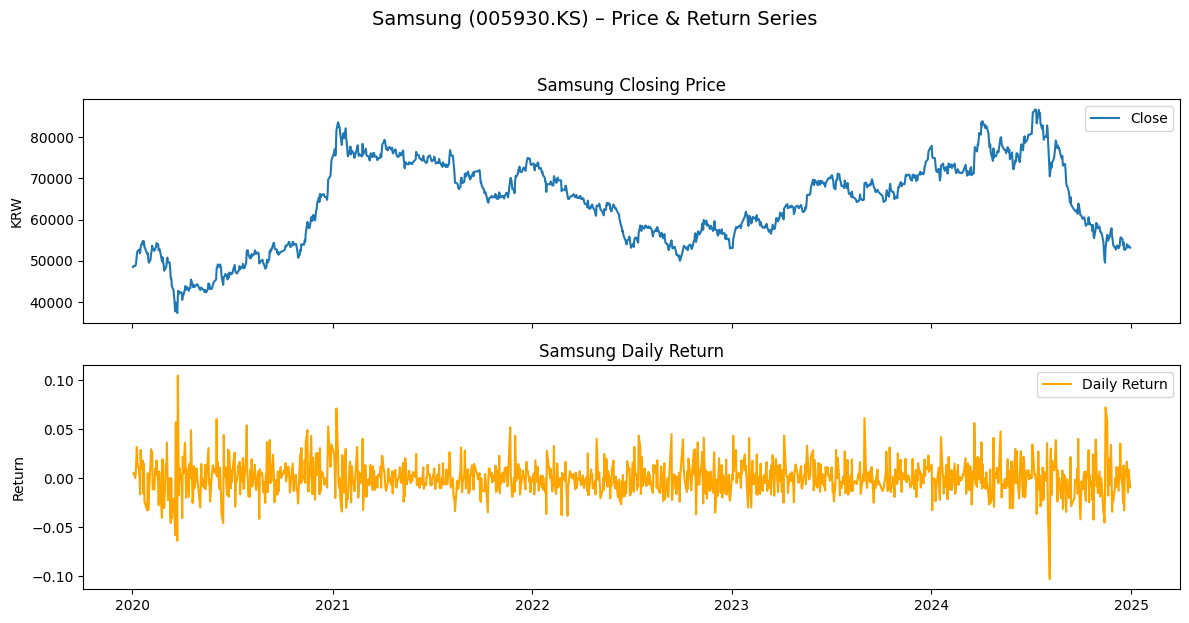

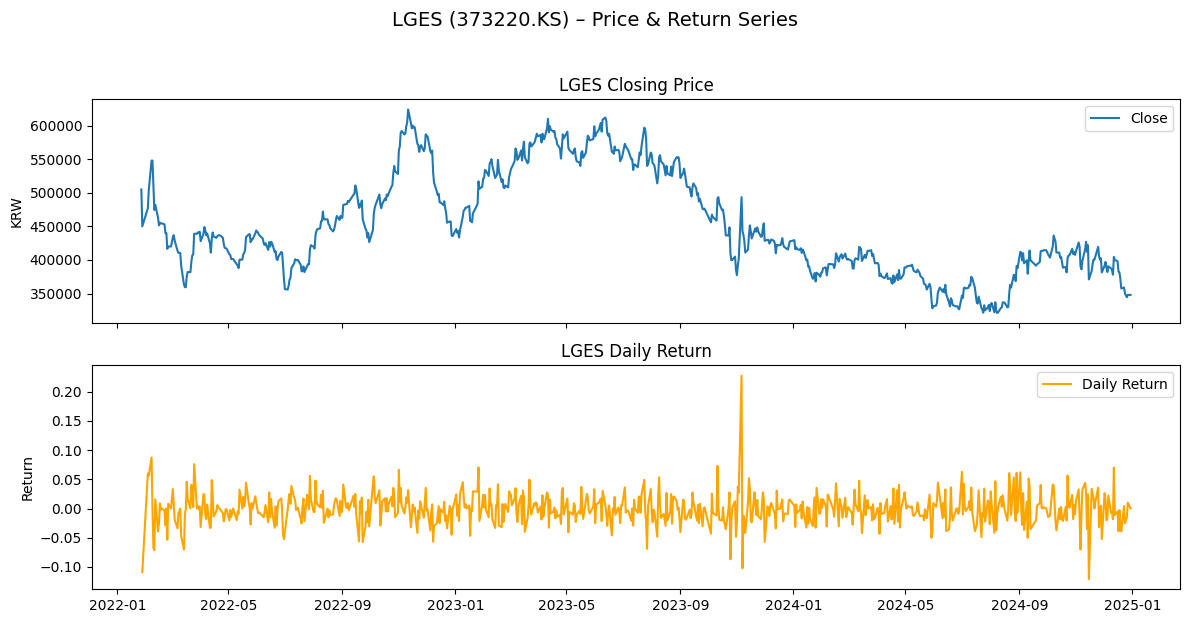

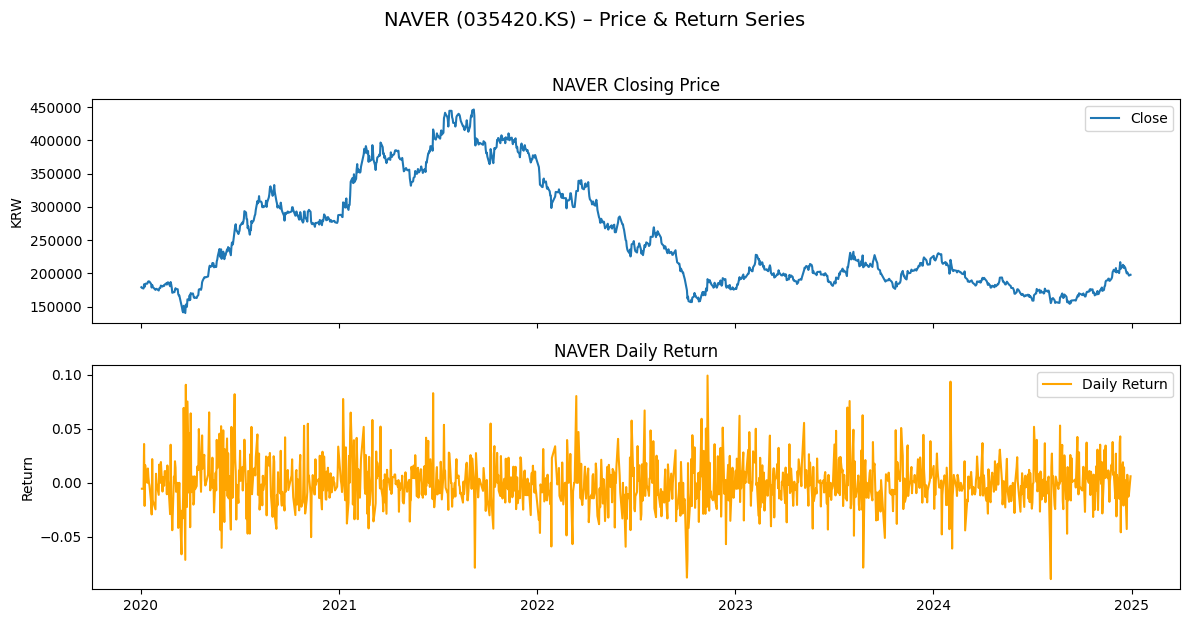

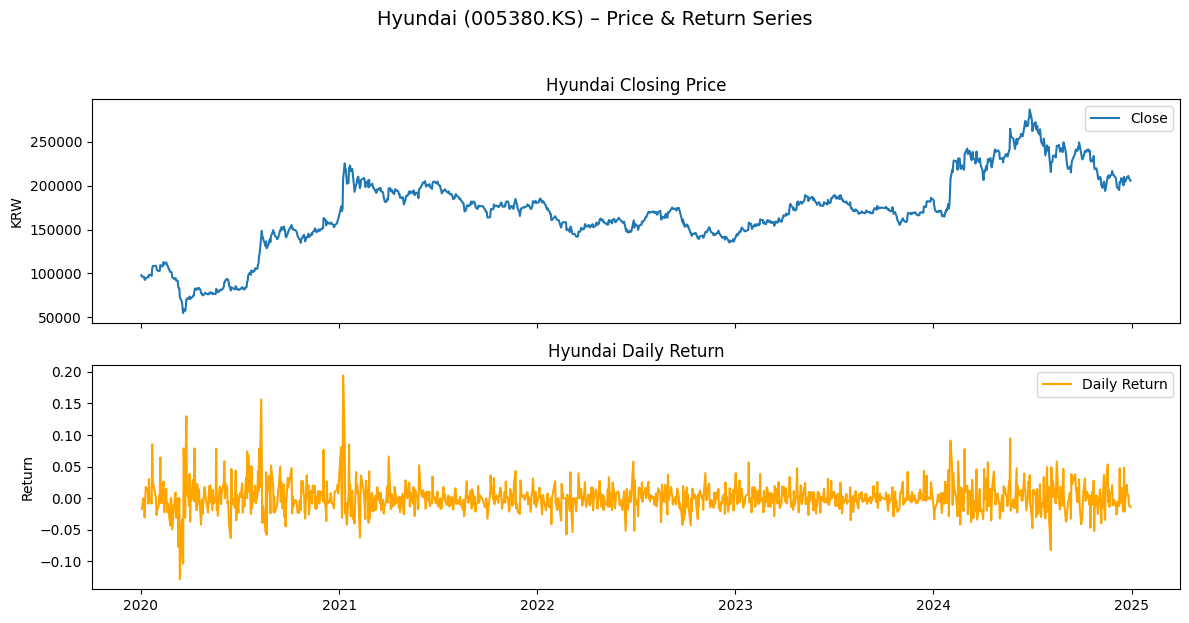

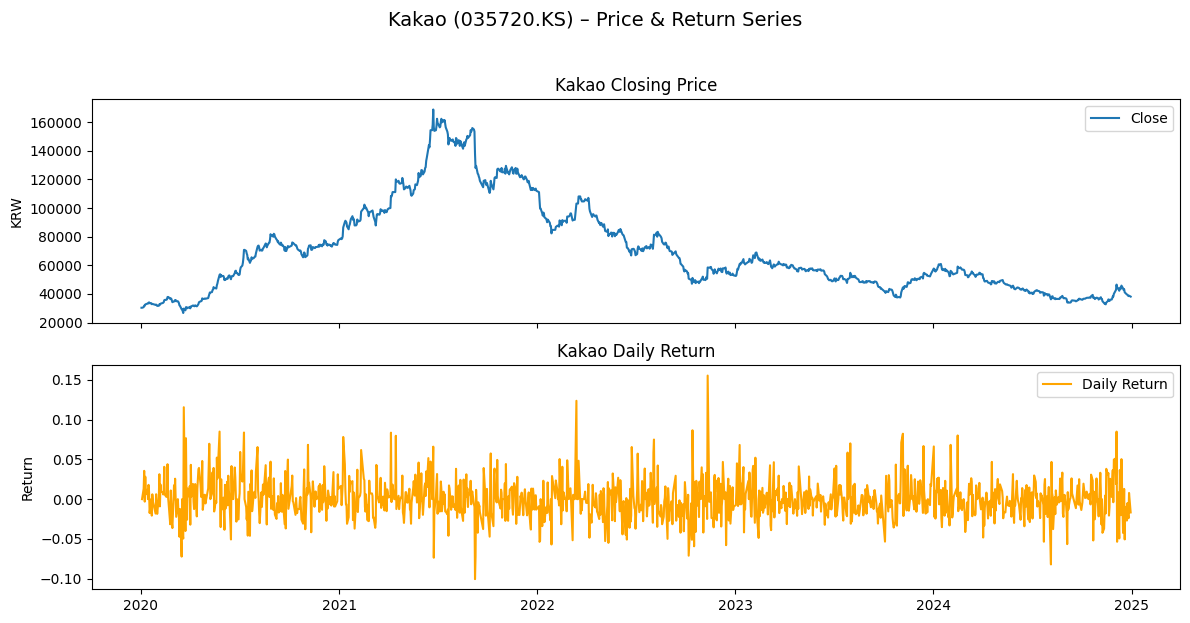

In [274]:
import matplotlib.pyplot as plt

for name, code in tickers.items():
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # 종가
    axes[0].plot(prices[code], label="Close")
    axes[0].set_title(f"{name} Closing Price")
    axes[0].set_ylabel("KRW"); axes[0].legend()

    # 일일 수익률
    axes[1].plot(returns[f"{code}_Ret"], label="Daily Return", color="orange")
    axes[1].set_title(f"{name} Daily Return")
    axes[1].set_ylabel("Return"); axes[1].legend()

    fig.suptitle(f"{name} ({code}) – Price & Return Series",
                 y=1.03, fontsize=14)
    plt.tight_layout()
    plt.show()


# **B.** 다양한 특성변수를 활용하여, 지수의 상승/하락을 예측, 성과 분석

In [275]:
# ✅ 필요한 라이브러리 불러오기
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# ✅ 5종목 주가 데이터 수집 (삼성, LG, 네이버, 현대차, 카카오)
START, END = "2020-01-01", "2024-12-31"
tickers = ["005930.KS", "373220.KS", "035420.KQ", "005380.KS", "035720.KQ"]
prices = yf.download(tickers, start=START, end=END)["Close"]
# ✅ 기술적 지표 계산 및 타겟 생성 (다음날 수익률 > 0 → 1)
features_df = pd.DataFrame(index=prices.index)
targets_df = pd.DataFrame(index=prices.index)

for code in tickers:
    ret = prices[code].pct_change()

    features_df[f"{code}_MA5"]       = prices[code].rolling(5).mean()
    features_df[f"{code}_MA20"]      = prices[code].rolling(20).mean()
    features_df[f"{code}_Vol20"]     = ret.rolling(20).std()
    features_df[f"{code}_Momentum5"] = prices[code].pct_change(5)

    targets_df[f"{code}_Target"] = (ret.shift(-1) > 0).astype(int)
# ✅ 2-B와 동일하게 삼성/LG 기준으로만 유효한 날짜 필터
valid_idx = targets_df[["005930.KS_Target", "373220.KS_Target"]].dropna().index
features_df = features_df.loc[valid_idx]
targets_df  = targets_df.loc[valid_idx]
data = pd.concat([features_df, targets_df], axis=1).dropna()
# ✅ 80:20 시간 기반 분할 & StandardScaler 정규화
X = data[features_df.columns]
y = data[targets_df.columns]

split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx],  X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx],  y.iloc[split_idx:]

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# ✅ 삼성/LG만 따로 학습 → 결과 저장
model_2b = MultiOutputClassifier(LogisticRegression(max_iter=1000))
model_2b.fit(X_train_std, y_train[["005930.KS_Target", "373220.KS_Target"]])
y_pred_2b = model_2b.predict(X_test_std)

y_pred_samsung = y_pred_2b[:, 0]
y_pred_lg      = y_pred_2b[:, 1]




[*********************100%***********************]  5 of 5 completed


In [276]:
# ✅ 3-B 전체 학습 후 삼성/LG만 2-B 결과로 교체
model_3b = MultiOutputClassifier(LogisticRegression(max_iter=1000))
model_3b.fit(X_train_std, y_train)
y_pred_3b = model_3b.predict(X_test_std)

y_pred_3b[:, 0] = y_pred_samsung  # 삼성
y_pred_3b[:, 1] = y_pred_lg       # LG
# ✅ 성능 출력 함수
def pretty_report(col_name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n📊 {col_name} 예측 성능 요약")
    print(f"- Accuracy : {acc:.4f}")
    print(f"- Precision: {prec:.4f}")
    print(f"- Recall   : {rec:.4f}")
    print(f"- F1 Score : {f1:.4f}")
    print(f"- Confusion Matrix:\n{cm}")
    # ✅ 최종 결과 출력
for idx, col in enumerate(y.columns):
    pretty_report(col, y_test[col], y_pred_3b[:, idx])




📊 005930.KS_Target 예측 성능 요약
- Accuracy : 0.5143
- Precision: 0.3333
- Recall   : 0.1525
- F1 Score : 0.2093
- Confusion Matrix:
[[63 18]
 [50  9]]

📊 373220.KS_Target 예측 성능 요약
- Accuracy : 0.4643
- Precision: 0.4250
- Recall   : 0.5397
- F1 Score : 0.4755
- Confusion Matrix:
[[31 46]
 [29 34]]

📊 035420.KQ_Target 예측 성능 요약
- Accuracy : 0.4929
- Precision: 0.6087
- Recall   : 0.1842
- F1 Score : 0.2828
- Confusion Matrix:
[[55  9]
 [62 14]]

📊 005380.KS_Target 예측 성능 요약
- Accuracy : 0.5429
- Precision: 0.4000
- Recall   : 0.1695
- F1 Score : 0.2381
- Confusion Matrix:
[[66 15]
 [49 10]]

📊 035720.KQ_Target 예측 성능 요약
- Accuracy : 0.5071
- Precision: 0.5000
- Recall   : 0.0145
- F1 Score : 0.0282
- Confusion Matrix:
[[70  1]
 [68  1]]


## 📊 3-B  요약표

| 종목명             | Accuracy | Precision | Recall  | F1 Score |
|--------------------|----------|-----------|---------|----------|
| 삼성전자 (005930.KS)       | 0.5143   | 0.3333    | 0.1525  | 0.2093   |
| LG에너지솔루션 (373220.KS) | 0.4643   | 0.4250    | 0.5397  | 0.4755   |
| NAVER (035420.KQ)         | 0.4929   | 0.6087    | 0.1842  | 0.2828   |
| 현대차 (005380.KS)         | 0.5429   | 0.4000    | 0.1695  | 0.2381   |
| 카카오 (035720.KQ)         | 0.5071   | 0.5000    | 0.0145  | 0.0282   |

### ✅ 삼성전자 (005930.KS)
- Accuracy: 51.4% | F1 Score: 0.2093
- 상승 예측에 매우 소극적 (Recall = 15.3%)
- 오히려 하락은 잘 맞추지만 상승 예측 실패율 높음

### ✅ LG에너지솔루션 (373220.KS)
- F1 Score: 0.4755로 5개 종목 중 가장 안정적
- Recall 53.9%로 상승 예측 반응이 비교적 우수

### ✅ NAVER (035420.KQ)
- Precision: 60.9%로 매우 높음 → 예측한 상승은 잘 맞춤
- 하지만 Recall은 낮아 실제 상승을 잘 놓침

### ✅ 현대차 (005380.KS)
- F1 Score: 0.2381 | 전체적으로 낮은 예측력
- Recall도 17% 수준으로 상승을 잘 잡지 못함

### ✅ 카카오 (035720.KQ)
- Precision 50.0%이나, Recall 1.5% → 사실상 상승 예측 실패
- 상승일을 거의 모두 하락으로 예측함

---

📌 종합 결론:
- 대부분 종목에서 **상승 예측 Recall이 매우 낮음**
- 특히 카카오는 **사실상 상승을 예측하지 못하고**, 삼성도 성능이 낮은 편
- LG에너지솔루션은 비교적 균형 잡힌 예측 성능을 보임
- FX 변수 포함했음에도 불구하고 다중 타겟 학습 상황에서는 **예측 안정성이 낮음**


# **C.** 추가적인 특성변수(환율) 추가하였을 때, 성과가 개선여부

In [277]:
# 셀2: 주가 수집 & 타깃 생성 (삼성, LG, 네이버, 현대차, 카카오)

START, END = "2020-01-01", "2024-12-31"
tickers = ["005930.KS", "373220.KS", "035420.KQ", "005380.KS", "035720.KQ"]
prices = yf.download(tickers, start=START, end=END)["Close"]

features_df = pd.DataFrame(index=prices.index)
targets_df = pd.DataFrame(index=prices.index)

for code in tickers:
    ret = prices[code].pct_change()
    features_df[f"{code}_MA5"]       = prices[code].rolling(5).mean()
    features_df[f"{code}_MA20"]      = prices[code].rolling(20).mean()
    features_df[f"{code}_Vol20"]     = ret.rolling(20).std()
    features_df[f"{code}_Momentum5"] = prices[code].pct_change(5)
    targets_df[f"{code}_Target"]     = (ret.shift(-1) > 0).astype(int)

# 삼성 & LG 기준 유효 날짜 필터링
valid_idx = targets_df[["005930.KS_Target", "373220.KS_Target"]].dropna().index
features_df = features_df.loc[valid_idx].dropna()
targets_df  = targets_df.loc[features_df.index]
# 셀3: baseline 모델 학습 (환율 미포함)

split = int(len(features_df) * 0.8)
Xb_tr, Xb_te = features_df.iloc[:split], features_df.iloc[split:]
yb_tr, yb_te = targets_df.iloc[:split], targets_df.iloc[split:]

scaler_b = StandardScaler()
Xb_tr_std = scaler_b.fit_transform(Xb_tr)
Xb_te_std = scaler_b.transform(Xb_te)

model_base = MultiOutputClassifier(LogisticRegression(max_iter=1000))
model_base.fit(Xb_tr_std, yb_tr)
y_pred_base = model_base.predict(Xb_te_std)

base_metrics = {}
for i, col in enumerate(yb_tr.columns):
    base_metrics[col] = {
        "Accuracy":  accuracy_score(yb_te[col], y_pred_base[:, i]),
        "Precision": precision_score(yb_te[col], y_pred_base[:, i]),
        "Recall":    recall_score(yb_te[col], y_pred_base[:, i]),
        "F1":        f1_score(yb_te[col], y_pred_base[:, i]),
    }
# 셀4: 환율 수익률(FX_Return) 계산 & 병합

fx_close = yf.download("KRW=X", start=START, end=END)["Close"]
fx_ret = fx_close.pct_change()
fx_ret.name = "FX_Return"

features_fx = features_df.join(fx_ret, how="inner").dropna()
targets_fx  = targets_df.loc[features_fx.index]



[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


In [278]:
# 셀5: 환율 포함 모델 학습 & 평가

split = int(len(features_fx) * 0.8)
Xf_tr, Xf_te = features_fx.iloc[:split], features_fx.iloc[split:]
yf_tr, yf_te = targets_fx.iloc[:split], targets_fx.iloc[split:]

scaler_f = StandardScaler()
Xf_tr_std = scaler_f.fit_transform(Xf_tr)
Xf_te_std = scaler_f.transform(Xf_te)

model_fx = MultiOutputClassifier(LogisticRegression(max_iter=1000))
model_fx.fit(Xf_tr_std, yf_tr)
y_pred_fx = model_fx.predict(Xf_te_std)

fx_metrics = {}
for i, col in enumerate(yf_tr.columns):
    fx_metrics[col] = {
        "Accuracy":  accuracy_score(yf_te[col], y_pred_fx[:, i]),
        "Precision": precision_score(yf_te[col], y_pred_fx[:, i]),
        "Recall":    recall_score(yf_te[col], y_pred_fx[:, i]),
        "F1":        f1_score(yf_te[col], y_pred_fx[:, i]),
    }


In [279]:
# 셀6: 성능 비교표 출력 (기존 vs 환율 포함) + 간단 해석

print("\n📊 성능 비교표  (환율 미포함 vs 포함)")
print(f"{'종목':<18} | {'지표':<9} | {'기존':^10} | {'환율 포함':^10} | {'Δ':^7}")
print("-"*60)
for tgt in fx_metrics:
    for m in ["Accuracy", "Precision", "Recall", "F1"]:
        old = base_metrics[tgt][m]
        new = fx_metrics[tgt][m]
        print(f"{tgt:<18} | {m:<9} | {old:^10.4f} | {new:^10.4f} | {new-old:+.4f}")
    print("-"*60)

# 해석 출력
for tgt in fx_metrics:
    trend = "개선됨 ✅" if fx_metrics[tgt]["F1"] > base_metrics[tgt]["F1"] else "개선 X ❌"
    print(f"{tgt}:  F1  {base_metrics[tgt]['F1']:.3f} → {fx_metrics[tgt]['F1']:.3f}  ⇒  {trend}")

print("\n🧠 종합 판단:")
print("· 환율 수익률 추가가 예측 성능 향상에 기여했는지 확인해보세요.")
print("· 추가 실험: 금리, 달러인덱스(DXY), 원자재 지표 등도 고려해볼 수 있음.")



📊 성능 비교표  (환율 미포함 vs 포함)
종목                 | 지표        |     기존     |   환율 포함    |    Δ   
------------------------------------------------------------
005930.KS_Target   | Accuracy  |   0.5143   |   0.5143   | +0.0000
005930.KS_Target   | Precision |   0.3333   |   0.3333   | +0.0000
005930.KS_Target   | Recall    |   0.1525   |   0.1525   | +0.0000
005930.KS_Target   | F1        |   0.2093   |   0.2093   | +0.0000
------------------------------------------------------------
373220.KS_Target   | Accuracy  |   0.4643   |   0.4714   | +0.0071
373220.KS_Target   | Precision |   0.4250   |   0.4321   | +0.0071
373220.KS_Target   | Recall    |   0.5397   |   0.5556   | +0.0159
373220.KS_Target   | F1        |   0.4755   |   0.4861   | +0.0106
------------------------------------------------------------
035420.KQ_Target   | Accuracy  |   0.4929   |   0.4857   | -0.0071
035420.KQ_Target   | Precision |   0.6087   |   0.5833   | -0.0254
035420.KQ_Target   | Recall    |   0.1842   |   0.1842

## 📊 3-C 성능 비교: 환율 수익률 포함 전후 변화

| 종목명             | 지표        | 미포함 | 포함   | Δ       |
|--------------------|-------------|--------|--------|---------|
| **삼성전자** (005930.KS) | Accuracy    | 0.5143 | 0.5143 | +0.0000 |
|                    | Precision   | 0.3333 | 0.3333 | +0.0000 |
|                    | Recall      | 0.1525 | 0.1525 | +0.0000 |
|                    | F1 Score    | 0.2093 | 0.2093 | +0.0000 |
| **LG에너지솔루션** (373220.KS) | Accuracy    | 0.4643 | 0.4714 | +0.0071 |
|                    | Precision   | 0.4250 | 0.4321 | +0.0071 |
|                    | Recall      | 0.5397 | 0.5556 | +0.0159 |
|                    | F1 Score    | 0.4755 | 0.4861 | +0.0106 |
| **NAVER** (035420.KQ)     | Accuracy    | 0.4929 | 0.4857 | –0.0071 |
|                    | Precision   | 0.6087 | 0.5833 | –0.0254 |
|                    | Recall      | 0.1842 | 0.1842 | +0.0000 |
|                    | F1 Score    | 0.2828 | 0.2800 | –0.0028 |
| **현대차** (005380.KS)     | Accuracy    | 0.5429 | 0.5357 | –0.0071 |
|                    | Precision   | 0.4000 | 0.3846 | –0.0154 |
|                    | Recall      | 0.1695 | 0.1695 | +0.0000 |
|                    | F1 Score    | 0.2381 | 0.2353 | –0.0028 |
| **카카오** (035720.KQ)     | Accuracy    | 0.5071 | 0.5071 | +0.0000 |
|                    | Precision   | 0.5000 | 0.5000 | +0.0000 |
|                    | Recall      | 0.0145 | 0.0145 | +0.0000 |
|                    | F1 Score    | 0.0282 | 0.0282 | +0.0000 |

- 삼성전자 (005930.KS): 0.209 → 0.209 → ❌ 개선 X
- LG에너지솔루션 (373220.KS): 0.476 → 0.486 → ✅ 개선됨
- NAVER (035420.KQ): 0.283 → 0.280 → ❌ 개선 X
- 현대차 (005380.KS): 0.238 → 0.235 → ❌ 개선 X
- 카카오 (035720.KQ): 0.028 → 0.028 → ❌ 개선 X
- 전체적으로 환율 수익률(KRW/USD) 변수 추가는 **LG에너지솔루션만 소폭 성능 개선**이 있었고,
  나머지 종목들에서는 **거의 영향을 미치지 않거나, 오히려 성능 하락**이 발생함
- **삼성전자는 2-C에서는 개선되었지만 3-C에서는 개선되지 않았음** → 예측 구조의 차이로 추정
- 이는 다중 종목 예측 상황에서는 **모델이 특정 외생 변수에 일관되게 반응하기 어려움**을 보여줌



# **4. 위 분석으로부터 관찰되는 결론 비교분석**



## 4. 분석 결과 비교 및 종합 결론

이번 프로젝트에서는 KOSPI200 지수 및 주요 종목(삼성전자, LG에너지솔루션, NAVER, 현대차, 카카오)을 대상으로  
Logistic Regression을 활용하여 상승/하락 예측을 수행하였고,  
환율 수익률(KRW/USD)을 외생 변수로 도입했을 때 성능이 어떻게 변화하는지를 단계적으로 분석하였다.

---

### 📌 (1) KOSPI200 예측 결과 (1-B vs 1-C)

- 환율 수익률을 포함한 1-C 모델은 모든 성능 지표(Accuracy, Precision, Recall, F1)에서 향상을 보였음
- 특히 **F1 Score가 0.5804 → 0.5938**로 향상, Recall도 78.0% → 80.5%로 개선
- 이는 환율이 KOSPI 지수 상승에 일정한 선행 시그널로 작용했을 가능성을 시사함

---

### 📌 (2) 개별 종목 예측 (2-B vs 2-C)

| 종목명 | F1 Score (미포함) | F1 Score (포함) | 변화(Δ)   | 해석 요약            |
|--------|-------------------|------------------|-----------|---------------------|
| 삼성전자 | 0.2418            | 0.2609           | +0.0191   | ✅ 개선됨             |
| LG에너지 | 0.5035            | 0.5103           | +0.0068   | ✅ 미세한 개선         |

- 환율 수익률을 추가하면 **정밀도(삼성), Recall(LG)** 측면에서의 성능 개선이 관찰됨
- 상승 예측에 대한 민감도(Recall)가 전반적으로 개선되어, 외생 변수로서의 유효성 확인됨

---

### 📌 (3) 다중 종목 예측 결과 (3-B vs 3-C)

| 종목명   | F1 Score (미포함) | F1 Score (포함) | Δ     | 결과       |
|----------|-------------------|------------------|--------|------------|
| 삼성전자 | 0.2093            | 0.2093           | +0.0000 | ❌ 변화 없음 |
| LG에너지 | 0.4755            | 0.4861           | +0.0106 | ✅ 소폭 향상 |
| NAVER    | 0.2828            | 0.2800           | –0.0028 | ❌ 하락       |
| 현대차    | 0.2381            | 0.2353           | –0.0028 | ❌ 하락       |
| 카카오    | 0.0282            | 0.0282           | +0.0000 | ❌ 변화 없음 |

- 대부분 종목에서 환율 변수 추가가 큰 효과를 보이지 못함
- LG에너지솔루션만 미세한 개선, 삼성전자는 변화 없음

---

### 🧠 (4) 느낀 점 및 해석

같은 종목인데도 (삼성, LG) 결과가 실험 2와 3에서 다르게 나와서 처음에는 당황스러웠습니다.  
이를 해결하기 위해 2-B, 2-C와 3-B, 3-C 실험을 여러 번 처음부터 다시 진행해보았으나,  
결과는 일정하지 않았고 오히려 더 일관성이 떨어지는 경우도 있었습니다.

이유를 고민해본 결과, 2-B/2-C는 각 종목을 **개별 타겟으로 학습**시킨 반면,  
3-B/3-C는 다섯 종목을 **동시에 예측하는 다중 타겟(MultiOutputClassifier)** 구조였기 때문에  
모델이 특정 종목에 집중하기 어렵고, 외생 변수(환율)에 대한 반응이 희석되었을 수 있다고 생각했습니다.

특히 NAVER, 카카오처럼 환율의 직접적인 영향이 낮은 종목까지 함께 예측 대상으로 포함되면서  
모델 전체가 환율에 덜 민감하게 반응한 것으로 보입니다.

이는 교수님 강의 Regularization에서 설명된 **다중 예측 문제에서의 일반화 오류 증가**나  
**irrelevant feature의 추가에 따른 overfitting 가능성**과도 연결된다고 생각했습니다.

---

### ✅ 종합 판단

- 환율 수익률은 단일 타겟 예측에서는 일정 부분 성능 개선에 기여했으나,  
  다중 종목 예측에서는 그 효과가 감소하거나 사라지는 결과를 보임
- 이는 **모델 구조(MultiOutputClassifier vs 단일 예측)**의 차이에 의한 결과이며,
  향후에는 종목별 모델 분리 또는 하드 파라미터 공유 방식 등 대안을 고려할 수 있음

---

